In [1]:
import torch
import torch.nn as nn

In [7]:
x = torch.tensor([
    [
        [
            [2, 1, 3, 0],
            [4, 6, 5, 2],
            [8, 1, 2, 7],
            [3, 9, 0, 4]
        ]
    ]
])
print(x.shape)
print(x)

torch.Size([1, 1, 4, 4])
tensor([[[[2, 1, 3, 0],
          [4, 6, 5, 2],
          [8, 1, 2, 7],
          [3, 9, 0, 4]]]])


so the shape is (1,1,4,4) (batch, channel, height, weight)

In [14]:
pool = nn.MaxPool2d(kernel_size=2, stride=2)
y = pool(x)
print(y.shape, '\n\n')
print(x)
y

torch.Size([1, 1, 2, 2]) 


tensor([[[[2, 1, 3, 0],
          [4, 6, 5, 2],
          [8, 1, 2, 7],
          [3, 9, 0, 4]]]])


tensor([[[[6, 5],
          [9, 7]]]])

In [20]:
x = x.type(torch.float32)
avg_pool = nn.AvgPool2d(kernel_size=2, stride=2)

y = avg_pool(x)
print(x, '\n\n')
print(y)

tensor([[[[2., 1., 3., 0.],
          [4., 6., 5., 2.],
          [8., 1., 2., 7.],
          [3., 9., 0., 4.]]]]) 


tensor([[[[3.2500, 2.5000],
          [5.2500, 3.2500]]]])


In [21]:
# Global Average
x = torch.tensor([
    [[[1.,2.],
      [3.,4.]],
     [[10.,20.],
      [30.,40.]]]
])
print(x.shape)

torch.Size([1, 2, 2, 2])


In [22]:
gap = nn.AdaptiveAvgPool2d(1)
y = gap(x)
print(y.shape)
print(y)

torch.Size([1, 2, 1, 1])
tensor([[[[ 2.5000]],

         [[25.0000]]]])


Fun Exercise: a cat image

torch.Size([3, 224, 224])


(np.float64(-0.5), np.float64(459.5), np.float64(395.5), np.float64(-0.5))

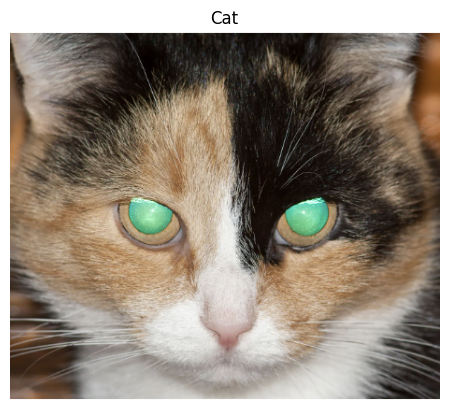

In [36]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

img = Image.open("cat.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

image = transform(img)
print(image.shape)
plt.imshow(img)
plt.title("Cat")
plt.axis("off")

In [37]:
image = image.unsqueeze(0)
image.shape

torch.Size([1, 3, 224, 224])

In [38]:
patch = image[0, 0, :4, :4]
print(patch.shape)
patch

torch.Size([4, 4])


tensor([[0.9804, 0.9804, 0.9804, 0.9804],
        [0.7294, 0.7333, 0.7255, 0.7333],
        [0.6510, 0.6627, 0.6588, 0.6549],
        [0.6196, 0.6745, 0.6745, 0.6627]])

In [ ]:
# Max Pooling
pool = nn.MaxPool2d(kernel_size=2, stride=2)
pooled = pool(patch.unsqueeze(0).unsqueeze(0))
pooled

tensor([[[[0.9804, 0.9804],
          [0.6745, 0.6745]]]])

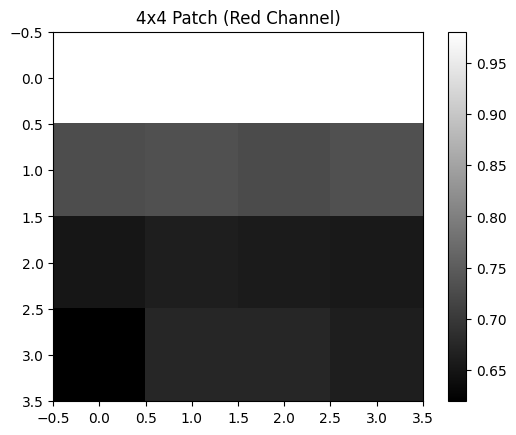

In [41]:
plt.imshow(patch, cmap="gray", interpolation="nearest")
plt.colorbar()
plt.title("4x4 Patch (Red Channel)")
plt.show()

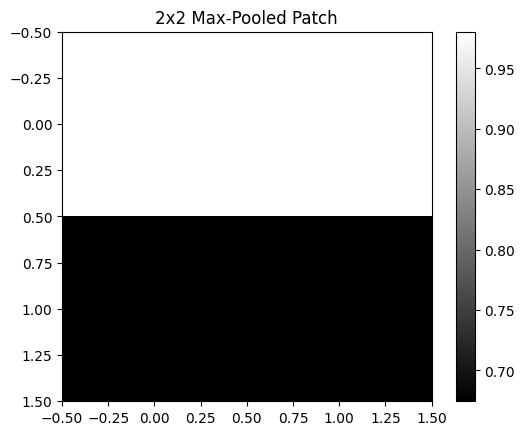

In [43]:
plt.imshow(pooled.squeeze(), cmap="gray", interpolation="nearest")
plt.colorbar()
plt.title("2x2 Max-Pooled Patch")
plt.show()